In [3]:
import sys
import os
cwd = os.getcwd()
functions_path = os.path.join(os.path.dirname(cwd), 'functions')
if functions_path not in sys.path:
    sys.path.append(functions_path)
import site
# Add user site-packages path manually
site_user_base = site.getusersitepackages()
if site_user_base not in sys.path:
    sys.path.append(site_user_base)

In [4]:
%matplotlib inline

In [5]:
#%load_ext memory_profiler

In [6]:
import warnings
import time
import numpy as np
import seaborn as sns
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import networkx as nx
from copy import deepcopy
from importlib import reload
import utils
import FCD_jax
import mpr_jax
mpr_jax=reload(mpr_jax)
FCD_jax=reload(FCD_jax)

warnings.simplefilter("ignore")

# Define a timer and a wrapper and the plot function
#### The wrapper should take as input G and the other latent variables 'params' and give as output the raw signal (r=firing rates, v=membrane potetials, bold_d=BOLD signal)

In [7]:
#jax.config.update("jax_enable_x64", True)

In [8]:
def timer(func):
    def wrapper(*args, **kwargs):
        import time
        start = time.time()
        result = func(*args, **kwargs)
        print(f"{func.__name__} took {time.time() - start:.2f} seconds")
        return result
    return wrapper

In [9]:
@timer
def wrapper(g, par, close=True):
    par = deepcopy(par)
    par["G"] = g
    # Create JAX simulation object
    sde = mpr_jax.MPR_sde.create(par)
    data = sde.run({})
    rv_t = data["rv_t"]
    rv_d = data["rv_d"]
    nn = par["weights"].shape[0]
    r = rv_d[:, :nn]
    v = rv_d[:, nn:]
    bold_d = data["bold_d"]
    bold_t = data["bold_t"]
    return rv_t, r, v, bold_t, bold_d

In [10]:
@timer
def alternative_wrapper(g, par, close=True):
    par = deepcopy(par)
    par["G"] = g
    # Create JAX simulation object
    sde = mpr_jax.MPR_sde.create(par)
    data = sde.run({})
    
    # Explicitly wait for the computation to finish before ending the timer
    data['rv_d'].block_until_ready()

    rv_t = data["rv_t"]
    rv_d = data["rv_d"]
    nn = par["weights"].shape[0]
    r = rv_d[:, :nn]
    v = rv_d[:, nn:]
    bold_d = data["bold_d"]
    bold_t = data["bold_t"]
    return rv_t, r, v, bold_t, bold_d

In [11]:
def plot(rv_t, r, v, bold_d, bold_t, g, close=True):
    step = 10
    fig, ax = plt.subplots(3, 1, figsize=(12, 6))
    ax[0].plot(rv_t[::step], r[::step, :], lw=0.1)
    ax[1].plot(rv_t[::step], v[::step, :], lw=0.1)
    ax[2].plot(bold_t, bold_d, lw=0.1)
    ax[0].set_ylabel("r")
    ax[1].set_ylabel("v")
    ax[2].set_ylabel("BOLD")
    # os.makedirs("data", exist_ok=True)
    # plt.savefig(f"data/control_vbi_{g:.3f}.png")
    # if close:
    #     plt.close()
    plt.show()

### Toy simulation with n=6 brain regoins, for checking functioning of the model's JAX implementation

In [12]:
nn = 6
weights = nx.to_numpy_array(nx.complete_graph(nn))
params = {"G": 0.25, 
          "weights": weights,
          "t_end": 30000,
          "dt": 0.01,
          "eta": jnp.array([-4.6]),
          "rv_decimate": 10,
          "noise_amp": 0.037,
          "tr": 1.0, #it was 500
          "seed":42
          }

#### Warm up for benefitting of the JIT compilation

In [13]:
rv_t, r, v, bold_t, bold_d =  wrapper(0.33, params)

wrapper took 3.29 seconds


In [14]:
rv_t, r, v, bold_t, bold_d =  wrapper(0.33, params)

wrapper took 2.52 seconds


In [15]:
#jnp.isnan(r).sum()

In [16]:
#!free -h

In [17]:
#!cat /sys/fs/cgroup/memory.max

wrapper took 2.39 seconds


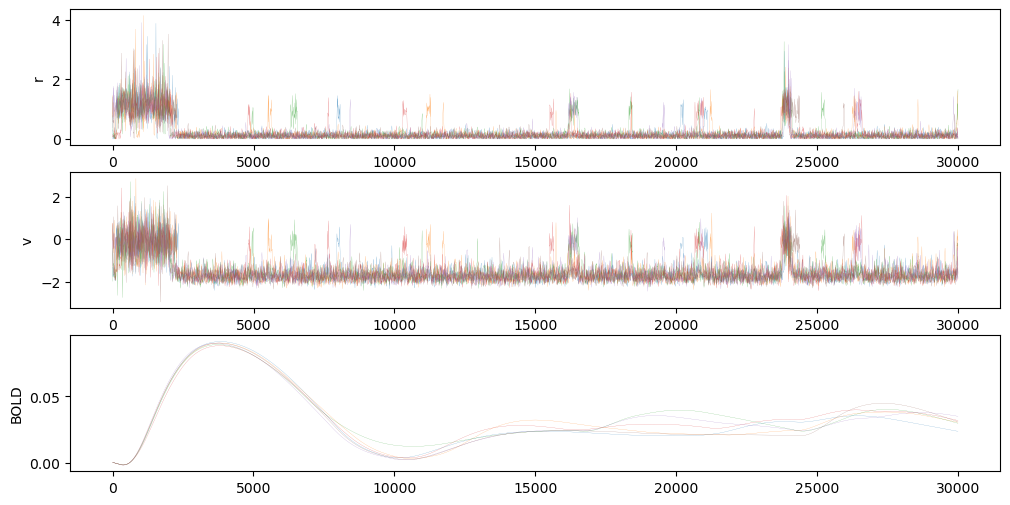

In [18]:
#params['t_end'] = 30_000
g = 0.33
rv_t, r, v, bold_t, bold_d = wrapper(g, params)
plot(rv_t, r, v, bold_d, bold_t, g)

wrapper took 2.47 seconds


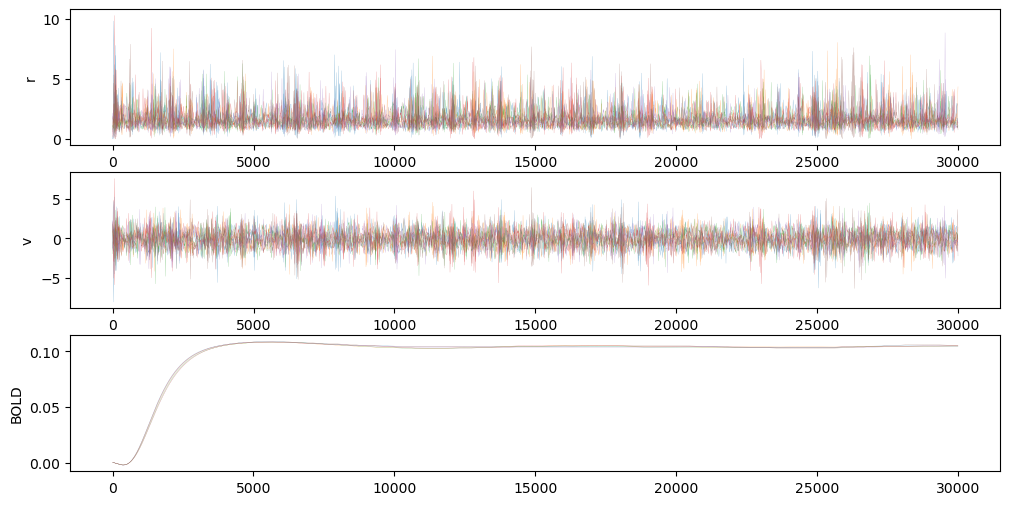

In [19]:
#params['t_end'] = 30000
g = 0.7
rv_t, r, v, bold_t, bold_d = wrapper(g, params)
plot(rv_t, r, v, bold_d, bold_t, g)

### Upload structural connectivity (SC) matrix, normalize it and print it

In [20]:
datapath = utils.DATA_ROOT
weights = np.loadtxt(datapath+"/weights.txt", delimiter=None)

In [21]:
nn = len(weights)
params["weights"] = jnp.array(weights)/jnp.max(weights)

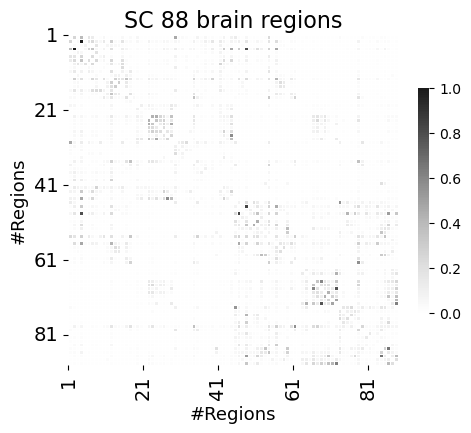

In [22]:
plt.figure(figsize=(5, 5))
mask = np.zeros_like(weights, dtype=bool)
mask[np.triu_indices_from(mask)] = False
#cmap = sns.diverging_palette(220, 10, as_cmap=True)
cmap='RdGy'
sns.heatmap(weights/np.max(weights), mask=mask, cmap=cmap, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('SC 88 brain regions',fontsize=16)
plt.ylabel('#Regions', fontsize=13.0)
plt.xlabel('#Regions', fontsize=13.0)
plt.xticks(np.r_[0:nn][::20], np.r_[1:nn+1][::20], fontsize=14)
plt.yticks(np.r_[0:nn][::20], np.r_[1:nn+1][::20], fontsize=14)
#plt.gca().invert_xaxis()
plt.tight_layout()
resultspath = utils.RESULTS_ROOT
#plt.savefig(os.path.join(resultspath,"SCmatrix.png"), dpi=800)
#plt.savefig(os.path.join(resultspath,"SCmatrix.eps"), dpi=800)
plt.show()

In [23]:
con = weights/np.max(weights)

In [24]:
con.shape, con.min(), con.max()

((88, 88), 0.0, 1.0)

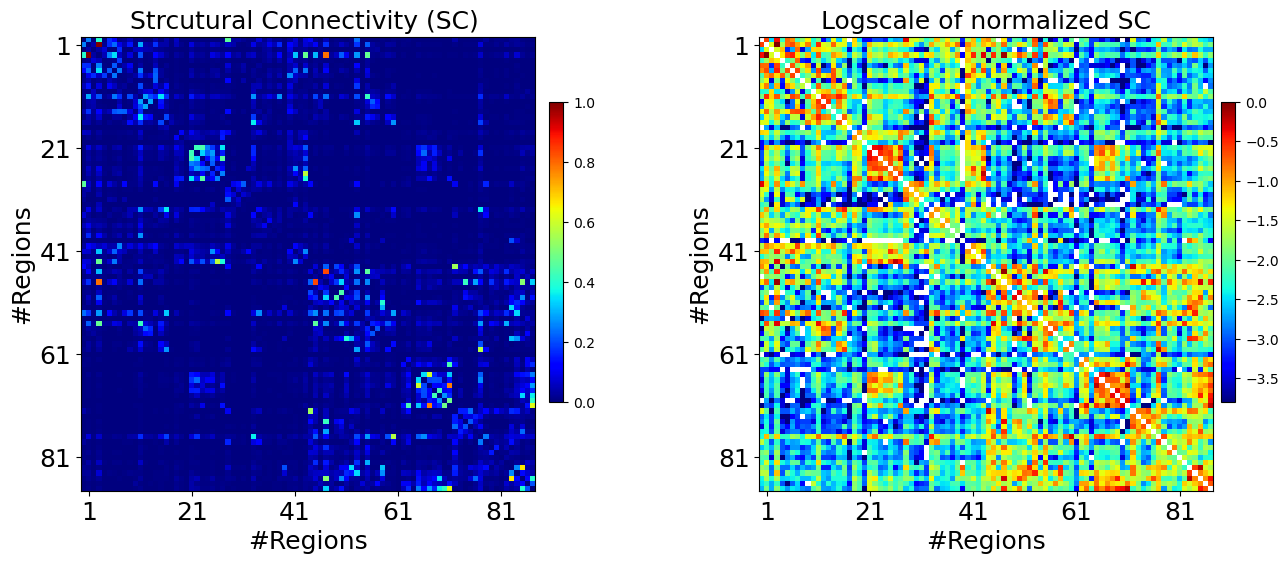

In [25]:
from matplotlib import colors, cm
import matplotlib.colors as mcolors

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
norm = colors.LogNorm(1e-7, con.max())
i=axs[0].imshow(con,cmap=cm.jet)
colorbar_ax = fig.add_axes([0.45, 0.3, 0.01, 0.5])
fig.colorbar(i, cax=colorbar_ax)
axs[0].set_title('Strcutural Connectivity (SC) ', fontsize=18.0)
axs[0].set_ylabel('#Regions', fontsize=18.0)
axs[0].set_xlabel('#Regions', fontsize=18.0)
axs[0].tick_params(labelsize=18)
axs[0].xaxis.set_ticks(np.r_[1:nn+1][::20])
axs[0].yaxis.set_ticks(np.r_[1:nn+1][::20])

i=axs[1].imshow(np.log10(con),cmap=cm.jet)
colorbar_ax = fig.add_axes([.93, 0.3, 0.01, 0.5])
fig.colorbar(i, cax=colorbar_ax)
axs[1].set_title('Logscale of normalized SC', fontsize=18.0)
axs[1].set_ylabel('#Regions', fontsize=18.0)
axs[1].set_xlabel('#Regions', fontsize=18.0)
axs[1].tick_params(labelsize=18)
axs[1].xaxis.set_ticks(np.r_[1:nn+1][::20])
axs[1].yaxis.set_ticks(np.r_[1:nn+1][::20])

fig.tight_layout(pad=2)

#plt.savefig(os.path.join(cwd+'/'+str(Res_dir),"SCmatrix_Normalized.png"), doi=800)
#plt.savefig(os.path.join(cwd+'/'+str(Res_dir),"SCmatrix_Normalized.eps"), doi=800)
plt.show()

In [26]:
con_positive=con.flatten()[con.flatten() != 0]
con_positive.shape[0]

7360

In [27]:
IC=con[np.r_[0:nn]][:,:].sum(axis=1)

In [28]:
print("The strongest connections received to each node from other nodes: \n", np.argsort(-IC)[0:5])

The strongest connections received to each node from other nodes: 
 [ 3 47 11 77 53]


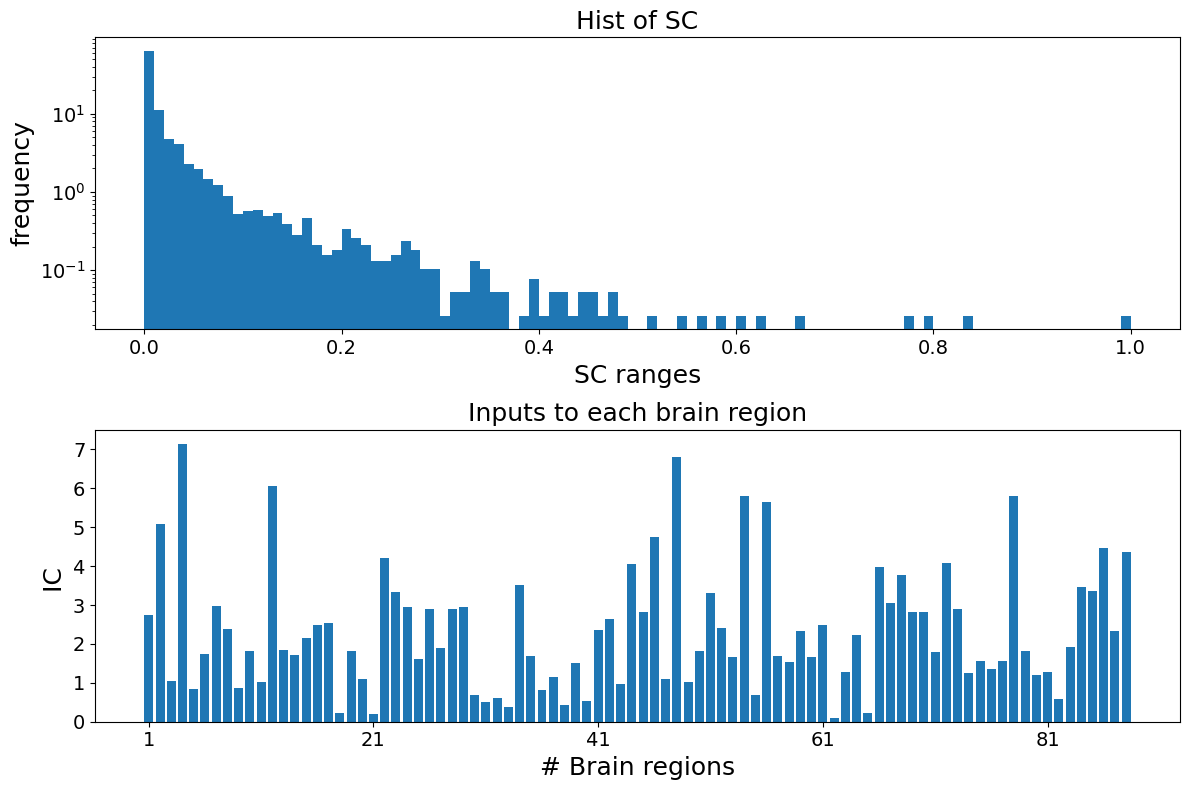

In [29]:
plt.figure(figsize=(12, 8))
plt.subplot(211)
plt.hist(con.flatten(), density=True, log=True, bins=100)
plt.title('Hist of SC', fontsize=18.0)
plt.ylabel('frequency', fontsize=18.0)
plt.xlabel('SC ranges', fontsize=18.0)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.subplot(212)
plt.bar(np.r_[0:nn], IC)

plt.title('Inputs to each brain region', fontsize=18.0)
plt.ylabel('IC ', fontsize=18.0)
plt.xlabel('# Brain regions', fontsize=18.0)
plt.xticks(np.r_[0:nn][::20], np.r_[1:nn+1][::20], fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
#plt.savefig(os.path.join(cwd+'/'+str(Res_dir),"Hist_SC.png"), doi=800)
#plt.savefig(os.path.join(cwd+'/'+str(Res_dir),"Hist_SC.eps"), doi=800)
plt.show()

### Replicate figure S1 from the paper (adding FC of firing rates for comparison)

In [30]:
t_end = 300_000
params['t_end'] = t_end

In [31]:
rv_t, r, v, bold_t, bold_d =  wrapper(0.33, params)

wrapper took 66.17 seconds


In [32]:
rv_t, r, v, bold_t, bold_d =  wrapper(0.33, params)

wrapper took 71.44 seconds


In [32]:
rv_t, r, v, bold_t, bold_d =  wrapper(0.33, params)

wrapper took 38.68 seconds


#### G=0, 0.5, 0.7: run simulation and save the output in variables

In [33]:
#%%memit
g = 0.0
rv_t, r, v, bold_t, bold_d = wrapper(g, params)

wrapper took 38.92 seconds


In [34]:
#%%memit
#plot(rv_t, r, v, bold_d, bold_t, g)
rv_t_G0 = rv_t
r_G0 = r
bold_t_G0 = bold_t
bold_G0 = bold_d

In [35]:
#%%memit
g = 0.5
rv_t, r, v, bold_t, bold_d = wrapper(g, params)

wrapper took 41.78 seconds


In [36]:
#%%memit
#plot(rv_t, r, v, bold_d, bold_t, g)
rv_t_G05 = rv_t
r_G05 = r
bold_t_G05 = bold_t
bold_G05 = bold_d

In [37]:
#%%memit
g = 0.7
rv_t, r, v, bold_t, bold_d = wrapper(g, params)
#plot(rv_t, r, v, bold_d, bold_t, g)

wrapper took 39.28 seconds


In [38]:
rv_t_G07 = rv_t
r_G07 = r
bold_t_G07 = bold_t
bold_G07 = bold_d 

In [39]:
#transpose for proper shape in the FCD calculation
bold_G0_T = bold_G0.T     # shape: (88, 60)
bold_G05_T = bold_G05.T
bold_G07_T = bold_G07.T

### Calculate the corrcoef of firing rates 

In [40]:
FC_r_G0 = np.corrcoef(r_G0.T)

In [41]:
FC_r_G05 = np.corrcoef(r_G05.T)

In [42]:
FC_r_G07 = np.corrcoef(r_G07.T)

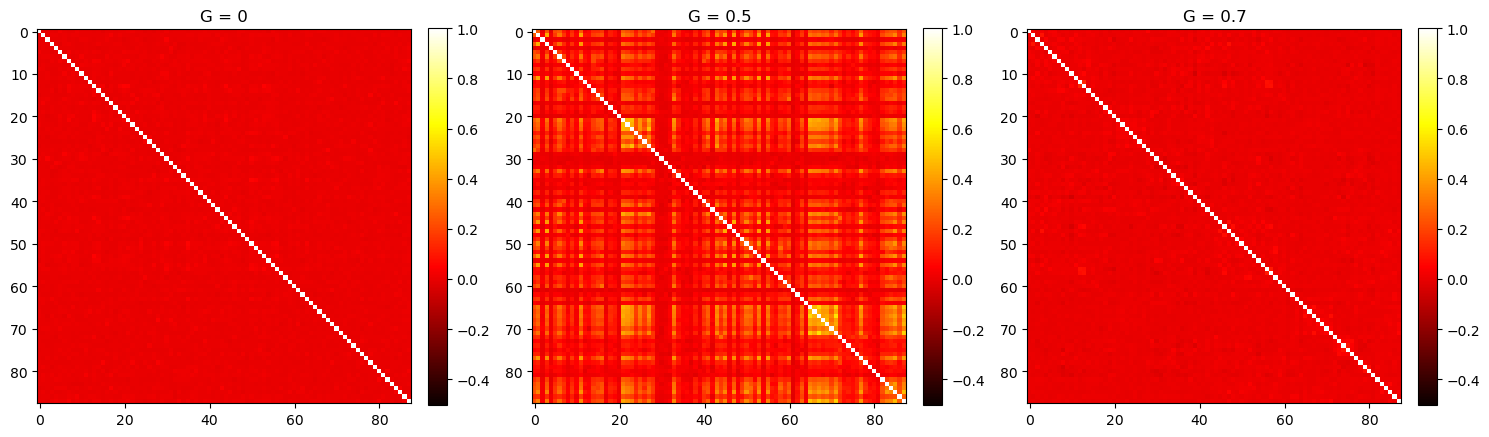

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# List of matrices and titles
matrices = [FC_r_G0, FC_r_G05, FC_r_G07]
titles = ["G = 0", "G = 0.5", "G = 0.7"]

for ax, mat, title in zip(axes, matrices, titles):
    im = ax.imshow(mat, vmin=-0.5, vmax=1, cmap='hot')
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### Calculate FC and FCD of the BOLD signal to replicate figure S1

In [1]:
wwidth = 30  # must be < 60
maxNwindows = 200
olap = 0.94

FCD_G0, FCvec_G0, _ = FCD_jax.extract_FCD(bold_G0[10000::500].T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)
FCD_G05, FCvec_G05, _ = FCD_jax.extract_FCD(bold_G05[10000::500].T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)
FCD_G07, FCvec_G07, _ = FCD_jax.extract_FCD(bold_G07[10000::500].T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)

FC_G0 = FCD_jax.get_fc(bold_G0[10000:].T)
FC_G05 = FCD_jax.get_fc(bold_G05[10000:].T)
FC_G07 = FCD_jax.get_fc(bold_G07[10000:].T)

NameError: name 'FCD_jax' is not defined

In [2]:
def plot_fc_fcd(rv_t, r, bold_t, bold_d, FC, FCD, label='G=?'):
    step = 10
    fig = plt.figure(figsize=(10, 5))  # Wide and not too tall

    # r plot (top-left, shorter height)
    ax1 = plt.subplot2grid((6, 5), (0, 0), colspan=3, rowspan=1)
    ax1.plot(rv_t[::step], r[::step, :], lw=0.1)
    ax1.set_ylabel("r")

    ax1.set_title(f"Firing Rates, {label}")
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # BOLD plot (middle-left, shorter height)
    ax2 = plt.subplot2grid((6, 5), (1, 0), colspan=3, rowspan=1)
    ax2.plot(bold_t, bold_d, lw=0.1)
    ax2.set_ylabel("BOLD")
    ax2.set_xlabel("Time (s)")
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # FC plot (full right height, top half)
    ax3 = plt.subplot2grid((6, 5), (0, 3), rowspan=2, colspan=1)
    im1 = ax3.imshow(FC, vmin=-0.5, vmax=1, cmap='hot')
    ax3.set_title("FC")
    plt.colorbar(im1, ax=ax3, fraction=0.046, pad=0.04)

    # FCD plot (full right height, bottom half)
    ax4 = plt.subplot2grid((6, 5), (0, 4), rowspan=2, colspan=1)
    im2 = ax4.imshow(FCD, vmin=0, vmax=1, cmap='hot')
    ax4.set_title("FCD")
    plt.colorbar(im2, ax=ax4, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()



plot_fc_fcd(rv_t_G0, r_G0, bold_t_G0, bold_G0, FC_G0, FCD_G0, label='G=0.0')
plot_fc_fcd(rv_t_G05, r_G05, bold_t_G05, bold_G05, FC_G05, FCD_G05, label='G=0.5')
plot_fc_fcd(rv_t_G07, r_G07, bold_t_G07, bold_G07, FC_G07, FCD_G07, label='G=0.7')

NameError: name 'rv_t_G0' is not defined

In [ ]:
# Suppose fcd_matrix is your output from extract_FCD
triu_idx = jnp.triu_indices(FCD_G0.shape[0], k=1)  # k=1 excludes the diagonal
upper_vals = FCD_G0[triu_idx]  # Extract upper triangular entries
var_upper = jnp.var(upper_vals)    # Compute variance
var_upper

In [43]:
# Suppose fcd_matrix is your output from extract_FCD
triu_idx = jnp.triu_indices(FCD_G05.shape[0], k=1)  # k=1 excludes the diagonal
upper_vals = FCD_G05[triu_idx]  # Extract upper triangular entries
var_upper = jnp.var(upper_vals)    # Compute variance
var_upper

Array(0.0037453, dtype=float32)

In [44]:
# Suppose fcd_matrix is your output from extract_FCD
triu_idx = jnp.triu_indices(FCD_G07.shape[0], k=1)  # k=1 excludes the diagonal
upper_vals = FCD_G07[triu_idx]  # Extract upper triangular entries
var_upper = jnp.var(upper_vals)    # Compute variance
var_upper

Array(0.0037453, dtype=float32)

In [49]:
bold_G05-bold_G07

Array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.04110844, -0.01159578, -0.03456914, ..., -0.0230356 ,
        -0.05638918, -0.0197117 ],
       [-0.04110102, -0.01158698, -0.03456831, ..., -0.02302122,
        -0.05639004, -0.01970224],
       [-0.04109359, -0.01157816, -0.03456751, ..., -0.02300688,
        -0.0563909 , -0.01969276]], dtype=float32)

In [52]:
np.shape(bold_G05_T[10000:])

(0, 300000)

In [47]:
params

{'G': 0.25,
 'weights': Array([[0.        , 0.25199234, 0.00302837, ..., 0.0039847 , 0.00350653,
         0.00223143],
        [0.25199234, 0.        , 0.03889066, ..., 0.01801084, 0.00605674,
         0.01163532],
        [0.00302837, 0.03889066, 0.        , ..., 0.00462225, 0.00207204,
         0.00207204],
        ...,
        [0.0039847 , 0.01801084, 0.00462225, ..., 0.        , 0.11635321,
         0.3970354 ],
        [0.00350653, 0.00605674, 0.00207204, ..., 0.11635321, 0.        ,
         0.20433535],
        [0.00223143, 0.01163532, 0.00207204, ..., 0.3970354 , 0.20433535,
         0.        ]], dtype=float32),
 't_end': 300000,
 'dt': 0.01,
 'eta': Array([-4.6], dtype=float32),
 'rv_decimate': 10,
 'noise_amp': 0.037,
 'tr': 1.0,
 'seed': 42}